# 📊 AI Hub 비전 데이터 탐색 및 품질 분석

> **학습 목표**: AI Hub 공공 비전 데이터를 불러오고, 데이터 품질 분석 및 EDA를 수행합니다.

---

## 📋 학습 내용

1. ✅ AI Hub 데이터 구조 이해
2. ✅ 이미지 파일 로드 및 시각화
3. ✅ 고급 이미지 통계 (Aspect Ratio, File Size)
4. ✅ Channel-wise RGB 분석
5. ✅ 불량 유형 분포 분석
6. ✅ 데이터 품질 메트릭 (Blur, Brightness, Contrast)
7. ✅ Augmentation 권장사항

**소요 시간**: 약 45분  
**난이도**: ⭐⭐ (중급)  
**사전 지식**: 이미지 처리 기초, OpenCV

---

## 🔧 Step 1: 라이브러리 Import

In [1]:
# 이미지 처리
from PIL import Image
import cv2
import numpy as np

# 데이터 분석
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 파일 처리
from pathlib import Path
import os
from collections import Counter

# 유틸리티
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


## 📂 Step 2: 이미지 데이터 로드

In [2]:
# 데이터 폴더 설정 — KAMP 실제 데이터 우선, 없으면 샘플 폴더 폴백
kamp_dir = Path('../../dataset/part1-2/시지트로닉스_이미지')
fallback_dir = Path('../data')

if kamp_dir.exists() and any(kamp_dir.iterdir()):
    data_dir = kamp_dir
    print(f"✅ KAMP 실제 데이터 사용: {data_dir.resolve()}")
else:
    data_dir = fallback_dir
    print(f"ℹ️ KAMP 데이터 없음 → 샘플 폴더 사용: {data_dir}")

# 이미지 확장자
image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff']

# 모든 이미지 파일 찾기
image_files = []
for ext in image_extensions:
    image_files.extend(list(data_dir.rglob(ext)))

print(f"📂 데이터 경로: {data_dir}")
print(f"🖼️ 발견된 이미지: {len(image_files):,}개")

# 디렉토리 구조 확인
if len(image_files) > 0:
    # 서브디렉토리별 이미지 개수
    dir_counts = Counter([f.parent.name for f in image_files])
    print(f"\n📁 디렉토리별 분포:")
    for dir_name, count in dir_counts.most_common(10):
        print(f"   - {dir_name}: {count:,}개")
else:
    print("\n⚠️ 이미지 파일이 없습니다. 샘플 데이터를 생성합니다.")
    # 샘플 이미지 생성
    data_dir.mkdir(exist_ok=True, parents=True)
    for i in range(50):
        img_array = np.random.randint(0, 256, (224, 224, 3), dtype=np.uint8)
        img = Image.fromarray(img_array)
        img.save(data_dir / f'sample_{i:03d}.png')
    image_files = list(data_dir.glob('*.png'))
    print(f"✅ 샘플 이미지 {len(image_files)}개 생성")

ℹ️ KAMP 데이터 없음 → 샘플 폴더 사용: ../data
📂 데이터 경로: ../data
🖼️ 발견된 이미지: 25개

📁 디렉토리별 분포:
   - data: 10개
   - defect_images: 3개
   - scratch: 3개
   - normal: 3개
   - contamination: 3개
   - damage: 3개


## 🖼️ Step 3: 이미지 시각화

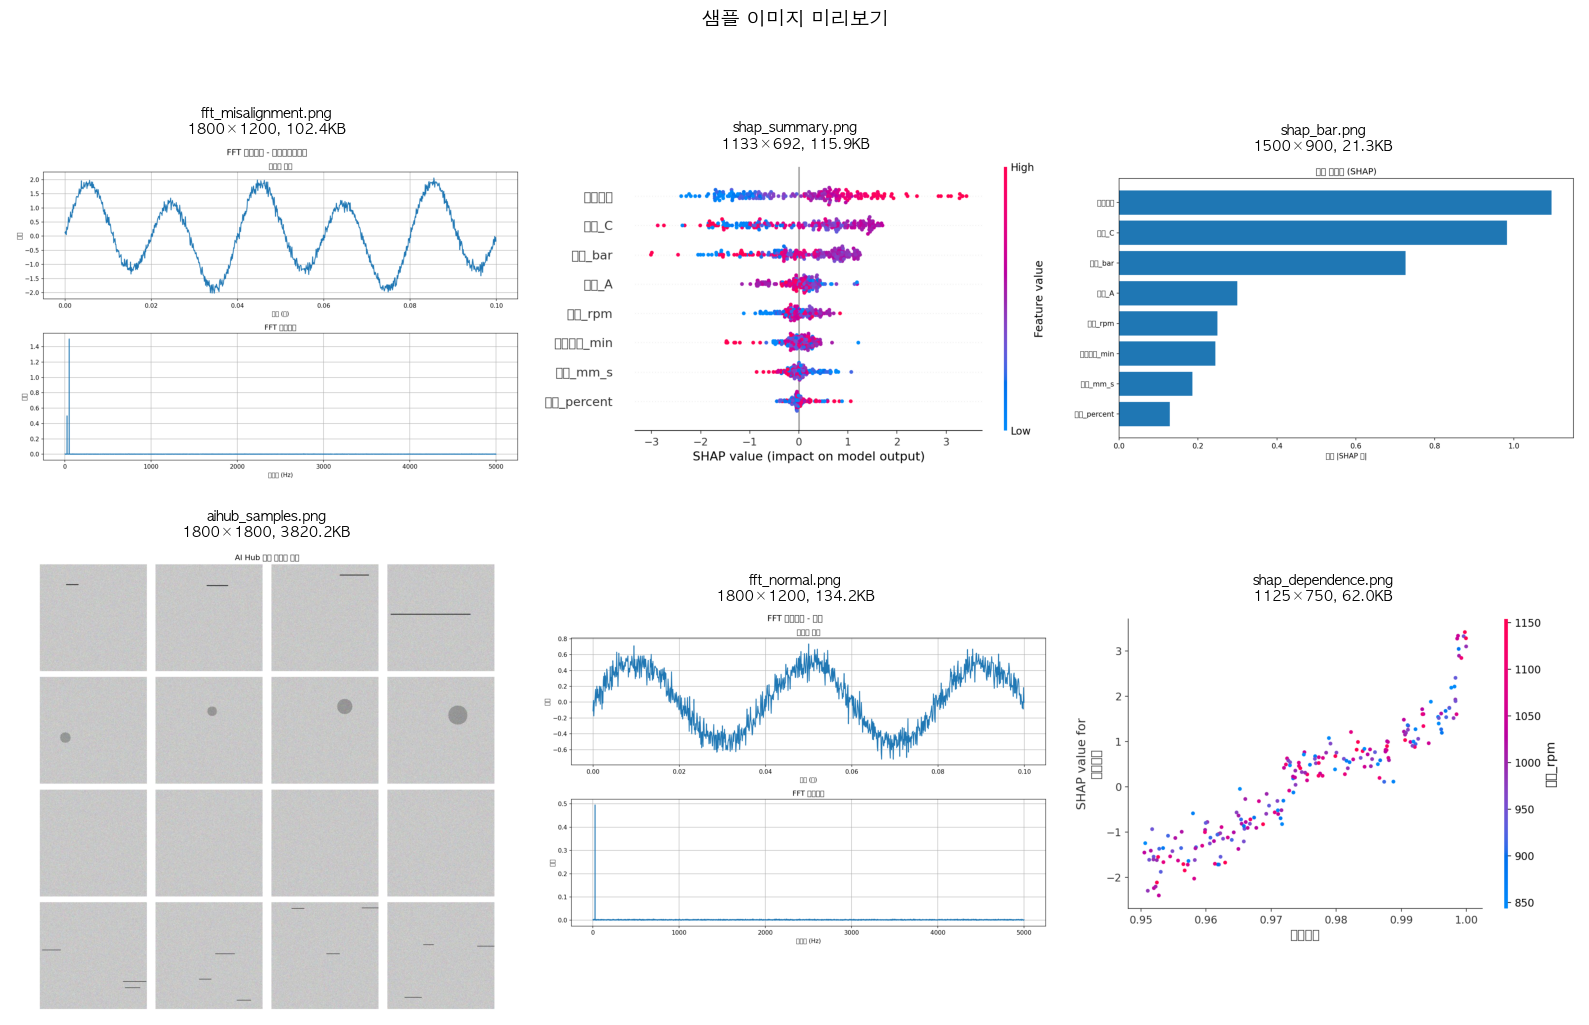

✅ 6개 이미지 시각화 완료


In [3]:
# 여러 이미지 시각화
n_images = min(6, len(image_files))
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx in range(n_images):
    if idx < len(image_files):
        img = Image.open(image_files[idx])
        axes[idx].imshow(img)
        
        # 파일 정보
        file_size = image_files[idx].stat().st_size / 1024  # KB
        axes[idx].set_title(
            f'{image_files[idx].name}\n{img.size[0]}×{img.size[1]}, {file_size:.1f}KB',
            fontsize=10
        )
        axes[idx].axis('off')

plt.suptitle('샘플 이미지 미리보기', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"✅ {n_images}개 이미지 시각화 완료")

## 📊 Step 4: 고급 이미지 통계 분석

In [4]:
# 이미지 메타데이터 수집
print("🔄 이미지 메타데이터 수집 중...")

metadata = []
for img_path in image_files:
    try:
        img = Image.open(img_path)
        file_stat = img_path.stat()
        
        metadata.append({
            'filename': img_path.name,
            'directory': img_path.parent.name,
            'width': img.width,
            'height': img.height,
            'aspect_ratio': img.width / img.height,
            'pixels': img.width * img.height,
            'megapixels': (img.width * img.height) / 1_000_000,
            'file_size_kb': file_stat.st_size / 1024,
            'mode': img.mode
        })
    except Exception as e:
        print(f"⚠️ 파일 읽기 실패: {img_path.name} - {e}")

df_meta = pd.DataFrame(metadata)

print(f"\n✅ {len(df_meta):,}개 이미지 메타데이터 수집 완료")
print(f"\n📊 이미지 통계:")
print(df_meta[['width', 'height', 'aspect_ratio', 'megapixels', 'file_size_kb']].describe().to_string())

🔄 이미지 메타데이터 수집 중...

✅ 25개 이미지 메타데이터 수집 완료

📊 이미지 통계:
             width       height  aspect_ratio  megapixels  file_size_kb
count    25.000000    25.000000     25.000000   25.000000     25.000000
mean    768.320000   552.320000      1.251121    0.708146    277.323047
std     698.384429   458.246178      0.444821    0.955624    739.349331
min     224.000000   224.000000      1.000000    0.050176     21.295898
25%     224.000000   224.000000      1.000000    0.050176    115.912109
50%     256.000000   256.000000      1.000000    0.065536    147.399414
75%    1500.000000   810.000000      1.500000    1.080000    147.431641
max    1800.000000  1800.000000      3.000000    3.240000   3820.173828


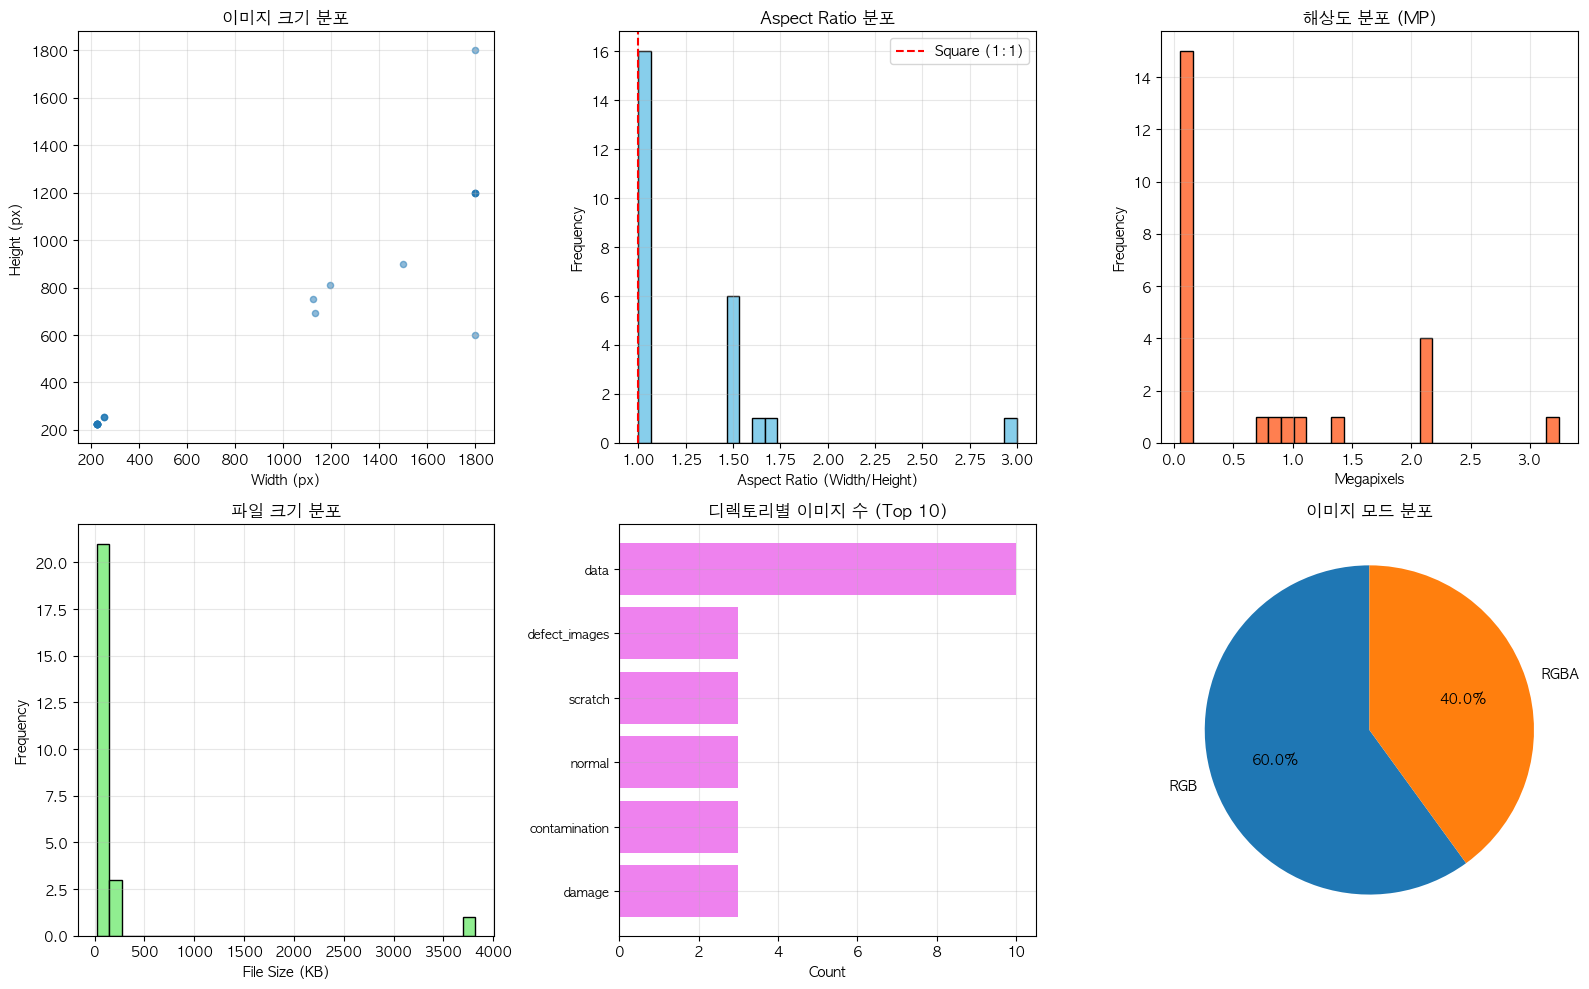


💡 통계 요약:
   - 평균 크기: 768×552px
   - 평균 Aspect Ratio: 1.25
   - 평균 파일 크기: 277.3KB
   - 평균 해상도: 0.71MP


In [5]:
# 통계 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 1. 이미지 크기 분포
axes[0].scatter(df_meta['width'], df_meta['height'], alpha=0.5, s=20)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].set_title('이미지 크기 분포', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. Aspect Ratio 히스토그램
axes[1].hist(df_meta['aspect_ratio'], bins=30, color='skyblue', edgecolor='black')
axes[1].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axes[1].set_xlabel('Aspect Ratio (Width/Height)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Aspect Ratio 분포', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Megapixels 분포
axes[2].hist(df_meta['megapixels'], bins=30, color='coral', edgecolor='black')
axes[2].set_xlabel('Megapixels')
axes[2].set_ylabel('Frequency')
axes[2].set_title('해상도 분포 (MP)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

# 4. 파일 크기 분포
axes[3].hist(df_meta['file_size_kb'], bins=30, color='lightgreen', edgecolor='black')
axes[3].set_xlabel('File Size (KB)')
axes[3].set_ylabel('Frequency')
axes[3].set_title('파일 크기 분포', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)

# 5. 디렉토리별 개수
dir_counts = df_meta['directory'].value_counts().head(10)
axes[4].barh(range(len(dir_counts)), dir_counts.values, color='violet')
axes[4].set_yticks(range(len(dir_counts)))
axes[4].set_yticklabels(dir_counts.index, fontsize=9)
axes[4].set_xlabel('Count')
axes[4].set_title('디렉토리별 이미지 수 (Top 10)', fontsize=12, fontweight='bold')
axes[4].invert_yaxis()
axes[4].grid(alpha=0.3)

# 6. 이미지 모드 분포
mode_counts = df_meta['mode'].value_counts()
axes[5].pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%', startangle=90)
axes[5].set_title('이미지 모드 분포', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 통계 요약:")
print(f"   - 평균 크기: {df_meta['width'].mean():.0f}×{df_meta['height'].mean():.0f}px")
print(f"   - 평균 Aspect Ratio: {df_meta['aspect_ratio'].mean():.2f}")
print(f"   - 평균 파일 크기: {df_meta['file_size_kb'].mean():.1f}KB")
print(f"   - 평균 해상도: {df_meta['megapixels'].mean():.2f}MP")

## 🎨 Step 5: Channel-wise RGB 분석

🔍 샘플 이미지 분석: fft_misalignment.png
   - Shape: (1200, 1800, 3)
   - Dtype: uint8


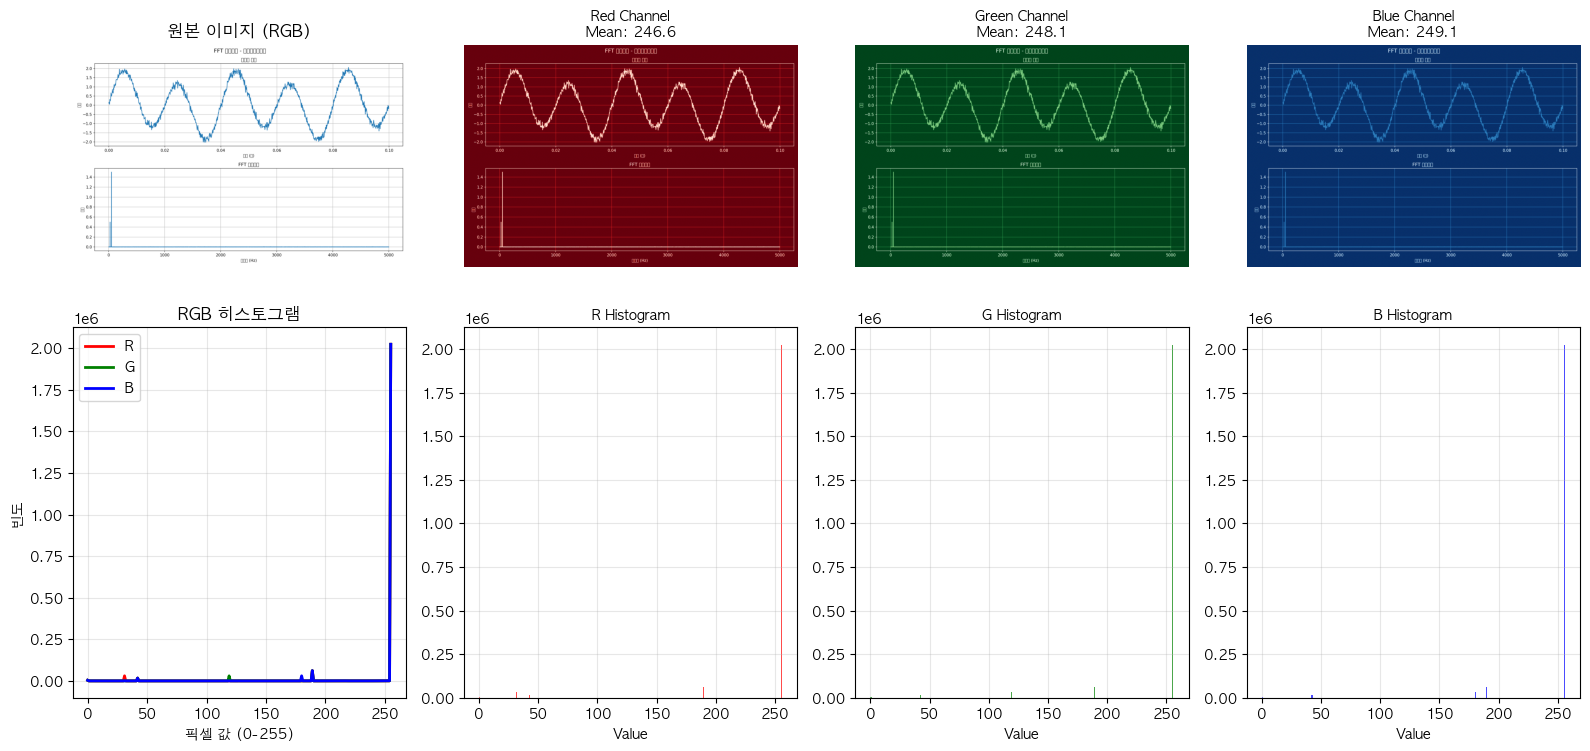


📊 채널별 통계:
   - Red:   Mean=246.56, Std=37.94
   - Green: Mean=248.06, Std=30.86
   - Blue:  Mean=249.10, Std=27.54


In [6]:
# 샘플 이미지 RGB 채널 분석
sample_img_path = image_files[0]
sample_img = cv2.imread(str(sample_img_path))
sample_img_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

print(f"🔍 샘플 이미지 분석: {sample_img_path.name}")
print(f"   - Shape: {sample_img_rgb.shape}")
print(f"   - Dtype: {sample_img_rgb.dtype}")

# Channel 분리
r_channel = sample_img_rgb[:, :, 0]
g_channel = sample_img_rgb[:, :, 1]
b_channel = sample_img_rgb[:, :, 2]

# 시각화
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 원본 이미지
axes[0, 0].imshow(sample_img_rgb)
axes[0, 0].set_title('원본 이미지 (RGB)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# R Channel
axes[0, 1].imshow(r_channel, cmap='Reds')
axes[0, 1].set_title(f'Red Channel\nMean: {r_channel.mean():.1f}', fontsize=10)
axes[0, 1].axis('off')

# G Channel
axes[0, 2].imshow(g_channel, cmap='Greens')
axes[0, 2].set_title(f'Green Channel\nMean: {g_channel.mean():.1f}', fontsize=10)
axes[0, 2].axis('off')

# B Channel
axes[0, 3].imshow(b_channel, cmap='Blues')
axes[0, 3].set_title(f'Blue Channel\nMean: {b_channel.mean():.1f}', fontsize=10)
axes[0, 3].axis('off')

# RGB 히스토그램
colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    hist = cv2.calcHist([sample_img_rgb], [i], None, [256], [0, 256])
    axes[1, 0].plot(hist, color=color, label=color.upper(), linewidth=2)

axes[1, 0].set_title('RGB 히스토그램', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('픽셀 값 (0-255)')
axes[1, 0].set_ylabel('빈도')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# R Channel 히스토그램
axes[1, 1].hist(r_channel.ravel(), bins=256, range=(0, 256), color='red', alpha=0.7)
axes[1, 1].set_title('R Histogram', fontsize=10)
axes[1, 1].set_xlabel('Value')
axes[1, 1].grid(alpha=0.3)

# G Channel 히스토그램
axes[1, 2].hist(g_channel.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
axes[1, 2].set_title('G Histogram', fontsize=10)
axes[1, 2].set_xlabel('Value')
axes[1, 2].grid(alpha=0.3)

# B Channel 히스토그램
axes[1, 3].hist(b_channel.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[1, 3].set_title('B Histogram', fontsize=10)
axes[1, 3].set_xlabel('Value')
axes[1, 3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 채널별 통계:")
print(f"   - Red:   Mean={r_channel.mean():.2f}, Std={r_channel.std():.2f}")
print(f"   - Green: Mean={g_channel.mean():.2f}, Std={g_channel.std():.2f}")
print(f"   - Blue:  Mean={b_channel.mean():.2f}, Std={b_channel.std():.2f}")

## 🔍 Step 6: 데이터 품질 메트릭

In [7]:
def calculate_blur_score(image):
    """Laplacian variance로 blur 점수 계산 (높을수록 선명)"""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_brightness(image):
    """평균 밝기 계산"""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return gray.mean()

def calculate_contrast(image):
    """표준편차로 대비 계산"""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return gray.std()

# 샘플 이미지에 대해 품질 메트릭 계산
print("🔄 데이터 품질 분석 중 (샘플 100개)...")

quality_metrics = []
sample_files = image_files[:min(100, len(image_files))]

for img_path in sample_files:
    try:
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        quality_metrics.append({
            'filename': img_path.name,
            'blur_score': calculate_blur_score(img_rgb),
            'brightness': calculate_brightness(img_rgb),
            'contrast': calculate_contrast(img_rgb)
        })
    except Exception as e:
        print(f"⚠️ 파일 분석 실패: {img_path.name}")

df_quality = pd.DataFrame(quality_metrics)

print(f"\n✅ {len(df_quality)}개 이미지 품질 분석 완료")
print(f"\n📊 품질 통계:")
print(df_quality[['blur_score', 'brightness', 'contrast']].describe().to_string())

🔄 데이터 품질 분석 중 (샘플 100개)...



✅ 25개 이미지 품질 분석 완료

📊 품질 통계:
         blur_score  brightness   contrast
count     25.000000   25.000000  25.000000
mean   29890.965329  171.695243  45.080484
std    23744.840059   56.077975   9.545831
min      202.592048  127.068260  22.529866
25%     1665.500850  127.423509  41.198157
50%    48603.875924  127.584243  49.311512
75%    48988.670183  243.481570  49.427083
max    49355.468956  249.767814  68.126337


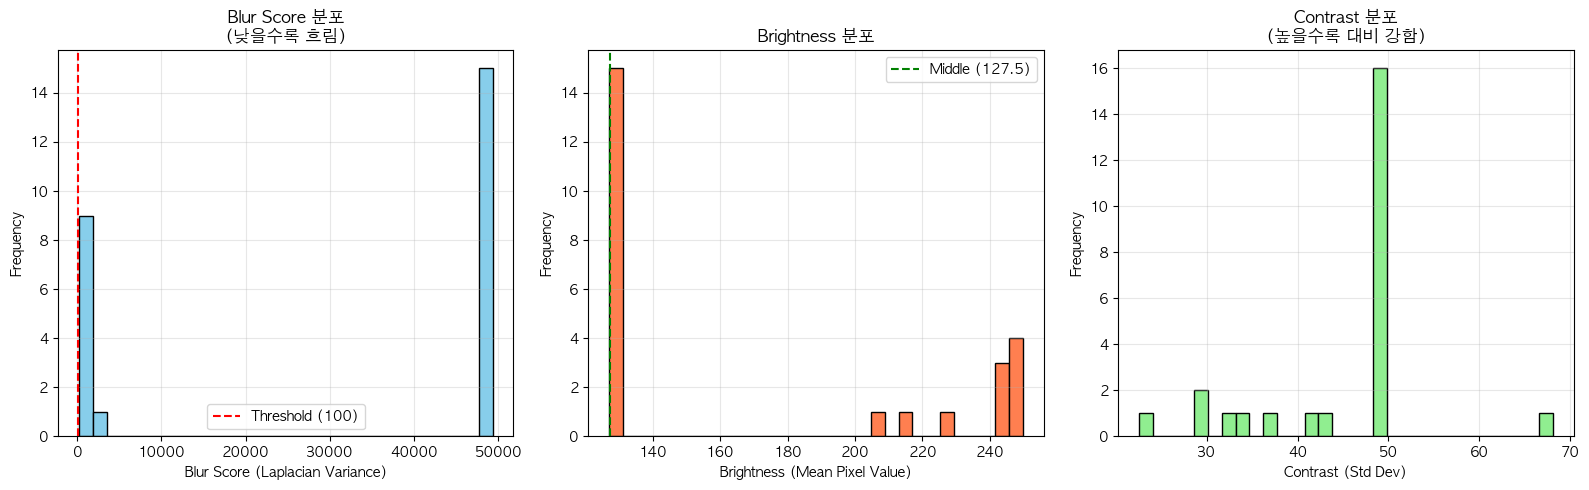


⚠️ 품질 이슈 감지:
   - 흐린 이미지 (blur<100): 0개 (0.0%)
   - 어두운 이미지 (brightness<50): 0개
   - 밝은 이미지 (brightness>200): 10개


In [8]:
# 품질 메트릭 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Blur Score
axes[0].hist(df_quality['blur_score'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(100, color='red', linestyle='--', label='Threshold (100)')
axes[0].set_xlabel('Blur Score (Laplacian Variance)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Blur Score 분포\n(낮을수록 흐림)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Brightness
axes[1].hist(df_quality['brightness'], bins=30, color='coral', edgecolor='black')
axes[1].axvline(127.5, color='green', linestyle='--', label='Middle (127.5)')
axes[1].set_xlabel('Brightness (Mean Pixel Value)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Brightness 분포', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Contrast
axes[2].hist(df_quality['contrast'], bins=30, color='lightgreen', edgecolor='black')
axes[2].set_xlabel('Contrast (Std Dev)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Contrast 분포\n(높을수록 대비 강함)', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 품질 이상치 탐지
blur_threshold = 100
brightness_low = 50
brightness_high = 200

blurry_images = df_quality[df_quality['blur_score'] < blur_threshold]
dark_images = df_quality[df_quality['brightness'] < brightness_low]
bright_images = df_quality[df_quality['brightness'] > brightness_high]

print(f"\n⚠️ 품질 이슈 감지:")
print(f"   - 흐린 이미지 (blur<{blur_threshold}): {len(blurry_images)}개 ({len(blurry_images)/len(df_quality)*100:.1f}%)")
print(f"   - 어두운 이미지 (brightness<{brightness_low}): {len(dark_images)}개")
print(f"   - 밝은 이미지 (brightness>{brightness_high}): {len(bright_images)}개")

## 🎨 Step 7: Augmentation 권장사항

In [9]:
# Augmentation 권장사항 생성
print("🔍 데이터 특성 기반 Augmentation 권장사항\n")
print("=" * 60)

# 1. 크기 분포 기반 권장
aspect_ratio_std = df_meta['aspect_ratio'].std()
print("\n1️⃣ Geometric Transformations:")
if aspect_ratio_std > 0.3:
    print("   ✅ 다양한 종횡비 → RandomCrop, RandomResizedCrop 권장")
else:
    print("   ⚠️ 일정한 종횡비 → CenterCrop, Resize만 사용")

print("   ✅ Rotation: ±15도 (제조 공정에서 회전 가능성)")
print("   ✅ Flip: Horizontal (수평 반전)")
print("   ⚠️ Vertical Flip: 신중히 사용 (제조 방향성 고려)")

# 2. 밝기 분포 기반 권장
brightness_std = df_quality['brightness'].std()
print("\n2️⃣ Color/Brightness Augmentations:")
if brightness_std > 30:
    print(f"   ✅ 밝기 편차 큼 (std={brightness_std:.1f}) → ColorJitter 사용")
    print("   - Brightness: ±0.2")
    print("   - Contrast: ±0.2")
else:
    print(f"   ⚠️ 밝기 일정 (std={brightness_std:.1f}) → ColorJitter 약하게")

# 3. Blur 기반 권장
blur_mean = df_quality['blur_score'].mean()
print("\n3️⃣ Noise/Blur Augmentations:")
if blur_mean < 500:
    print(f"   ⚠️ 평균 Blur 낮음 ({blur_mean:.1f}) → GaussianBlur 추가 권장")
    print("   - Kernel size: (3, 3) or (5, 5)")
else:
    print(f"   ✅ 선명도 양호 ({blur_mean:.1f})")

print("   ✅ GaussianNoise: sigma=0.01~0.05 (센서 노이즈 시뮬레이션)")

# 4. 제조 특화 권장
print("\n4️⃣ Manufacturing-Specific Augmentations:")
print("   ✅ ShiftScaleRotate: 조명/위치 변화 시뮬레이션")
print("   ✅ RandomBrightnessContrast: 조명 조건 변화")
print("   ✅ Cutout/CoarseDropout: 가려짐 시뮬레이션")
print("   ⚠️ Elastic Transform: 과도한 왜곡 주의")

# 5. Augmentation 강도 권장
print("\n5️⃣ 권장 Augmentation 강도:")
dataset_size = len(image_files)
if dataset_size < 500:
    print(f"   🔴 데이터 부족 ({dataset_size}개) → 강한 Augmentation 필요")
    print("   - Augmentation 배수: 10-20배")
elif dataset_size < 2000:
    print(f"   🟡 데이터 보통 ({dataset_size}개) → 중간 강도 Augmentation")
    print("   - Augmentation 배수: 5-10배")
else:
    print(f"   🟢 데이터 충분 ({dataset_size}개) → 약한 Augmentation")
    print("   - Augmentation 배수: 2-5배")

print("\n" + "=" * 60)

🔍 데이터 특성 기반 Augmentation 권장사항


1️⃣ Geometric Transformations:
   ✅ 다양한 종횡비 → RandomCrop, RandomResizedCrop 권장
   ✅ Rotation: ±15도 (제조 공정에서 회전 가능성)
   ✅ Flip: Horizontal (수평 반전)
   ⚠️ Vertical Flip: 신중히 사용 (제조 방향성 고려)

2️⃣ Color/Brightness Augmentations:
   ✅ 밝기 편차 큼 (std=56.1) → ColorJitter 사용
   - Brightness: ±0.2
   - Contrast: ±0.2

3️⃣ Noise/Blur Augmentations:
   ✅ 선명도 양호 (29891.0)
   ✅ GaussianNoise: sigma=0.01~0.05 (센서 노이즈 시뮬레이션)

4️⃣ Manufacturing-Specific Augmentations:
   ✅ ShiftScaleRotate: 조명/위치 변화 시뮬레이션
   ✅ RandomBrightnessContrast: 조명 조건 변화
   ✅ Cutout/CoarseDropout: 가려짐 시뮬레이션
   ⚠️ Elastic Transform: 과도한 왜곡 주의

5️⃣ 권장 Augmentation 강도:
   🔴 데이터 부족 (25개) → 강한 Augmentation 필요
   - Augmentation 배수: 10-20배



## 💾 Step 8: 결과 저장

In [10]:
# 출력 디렉토리 생성
output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# 메타데이터 저장
metadata_file = output_dir / '01_image_metadata.csv'
df_meta.to_csv(metadata_file, index=False, encoding='utf-8-sig')
print(f"✅ 메타데이터 저장: {metadata_file}")

# 품질 메트릭 저장
quality_file = output_dir / '01_quality_metrics.csv'
df_quality.to_csv(quality_file, index=False, encoding='utf-8-sig')
print(f"✅ 품질 메트릭 저장: {quality_file}")

# 통계 요약 저장
summary = pd.DataFrame({
    'metric': [
        'total_images', 'avg_width', 'avg_height', 'avg_aspect_ratio',
        'avg_file_size_kb', 'avg_blur_score', 'avg_brightness', 'avg_contrast'
    ],
    'value': [
        len(df_meta),
        df_meta['width'].mean(),
        df_meta['height'].mean(),
        df_meta['aspect_ratio'].mean(),
        df_meta['file_size_kb'].mean(),
        df_quality['blur_score'].mean(),
        df_quality['brightness'].mean(),
        df_quality['contrast'].mean()
    ]
})
summary_file = output_dir / '01_dataset_summary.csv'
summary.to_csv(summary_file, index=False, encoding='utf-8-sig')
print(f"✅ 통계 요약 저장: {summary_file}")

print("\n🎉 AI Hub 비전 데이터 탐색 완료!")

✅ 메타데이터 저장: ../outputs/01_image_metadata.csv
✅ 품질 메트릭 저장: ../outputs/01_quality_metrics.csv
✅ 통계 요약 저장: ../outputs/01_dataset_summary.csv

🎉 AI Hub 비전 데이터 탐색 완료!


---

## 🎯 학습 정리

### ✅ 완료한 내용
1. AI Hub 비전 데이터 로드 및 구조 파악
2. 고급 이미지 통계 (Aspect Ratio, File Size, Resolution)
3. Channel-wise RGB 분석 및 히스토그램
4. 데이터 품질 메트릭 (Blur, Brightness, Contrast)
5. 품질 이슈 탐지 (흐림, 과도한 밝기/어두움)
6. 데이터 특성 기반 Augmentation 권장사항 생성

### 💡 핵심 인사이트

- **이미지 품질 분석**:
  - Blur Score (Laplacian Variance): 선명도 측정
  - Brightness: 조명 조건 파악
  - Contrast: 대비 강도 분석
  - 품질 이슈 자동 탐지로 데이터 정제 가능

- **데이터 특성 파악**:
  - Aspect Ratio 분포 → 모델 입력 크기 결정
  - 파일 크기 → 메모리/저장 공간 계획
  - RGB 채널 분포 → 정규화 전략 수립

- **Augmentation 전략**:
  - 데이터 부족 시 강한 Augmentation (10-20배)
  - 제조 도메인 특화: ShiftScaleRotate, Cutout
  - 밝기 편차 고려: ColorJitter 강도 조절
  - 제조 방향성 고려: Vertical Flip 신중 사용

- **실무 활용**:
  - 데이터 수집 품질 검증
  - 모델 학습 전 전처리 계획 수립
  - Augmentation 파이프라인 설계
  - 이상 이미지 자동 필터링

### 📚 다음 단계
- **02_image_preprocessing.ipynb**: 이미지 전처리 및 Augmentation 실습
- **03_defect_classification.ipynb**: 불량 분류 모델 학습

### 🔗 참고 자료
- [AI Hub](https://www.aihub.or.kr/) - 공공 AI 데이터셋
- [Albumenta ions](https://albumentations.ai/) - Augmentation 라이브러리
- [OpenCV 문서](https://docs.opencv.org/) - 이미지 처리

---

*제조AI 교육 v12 Enhanced | Part 1-2 | 2025.02*